[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshtovar/MAT422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb)

# MAT 422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

**Topics:** singular value decomposition, low-rank matrix approximations, principal component analysis

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Singular value decomposition factors a matrix A into A = U Sigma V^T. The columns of U and V are orthonormal directions, and the singular values in Sigma measure how much each direction contributes to the matrix.

In [ ]:
# Make matrix A
A = np.array([
    [4, 0, 1],
    [1, 5, 2],
    [3, 1, 6],
    [0, 2, 4],
    [2, 3, 1],
], dtype=float)

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
A_reconstructed = U @ Sigma @ Vt

print("A =")
print(A)
print("\nSingular values =", s)
print("\nU shape, Sigma shape, Vt shape =", U.shape, Sigma.shape, Vt.shape)
print("\nU.T @ U =")
print(U.T @ U)
print("\nVt @ Vt.T =")
print(Vt @ Vt.T)
print("\nReconstruction error ||A - U Sigma Vt||_F =", np.linalg.norm(A - A_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(A, A_reconstructed))

A =
[[4. 0. 1.]
 [1. 5. 2.]
 [3. 1. 6.]
 [0. 2. 4.]
 [2. 3. 1.]]

Singular values = [9.5499 4.6567 3.7569]

U shape, Sigma shape, Vt shape = (5, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]

Vt @ Vt.T =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Reconstruction error ||A - U Sigma Vt||_F = 7.01289712984897e-15
Reconstruction is accurate? True


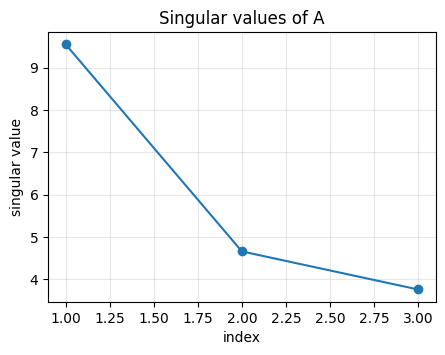

In [ ]:
# Plot the graph
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of A")
plt.grid(True, alpha=0.3)
plt.show()

Singular values that are big shows directions that carry more structure. Singular values that are smaller contribute less, so singular value decomposition helps with approximation

## 1.4.2 Low-Rank Matrix Approximations

A rank-k approximation keeps only the first k singular values and singular vectors. This gives a simpler matrix A_k that captures the strongest patterns in A.

In [ ]:
def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
# Approximate our matrix A using only the top k singular values,
# then measure how much error that introduces compared to the full matrix
errors = []
errors = []
for k in range(1, len(s) + 1):
    A_k = rank_k_approximation(U, s, Vt, k)
    error = np.linalg.norm(A - A_k, ord="fro")
    errors.append(error)
    print(f"Rank-{k} approximation:")
    print(A_k)
    print("Frobenius error =", error)
    print("matrix rank =", np.linalg.matrix_rank(A_k))
    print()

Rank-1 approximation:
[[1.0733 1.2473 1.8548]
 [1.9237 2.2355 3.3245]
 [2.7227 3.164  4.7053]
 [1.7307 2.0112 2.991 ]
 [1.3518 1.5709 2.3361]]
Frobenius error = 5.98326096600715
matrix rank = 1

Rank-2 approximation:
[[ 1.9721 -0.4893  2.5025]
 [ 0.5492  4.8912  2.334 ]
 [ 3.7492  1.1808  5.4449]
 [ 1.5438  2.3725  2.8562]
 [ 0.7662  2.7023  1.9141]]
Frobenius error = 3.7569427561724065
matrix rank = 2

Rank-3 approximation:
[[ 4.  0.  1.]
 [ 1.  5.  2.]
 [ 3.  1.  6.]
 [-0.  2.  4.]
 [ 2.  3.  1.]]
Frobenius error = 7.01289712984897e-15
matrix rank = 3



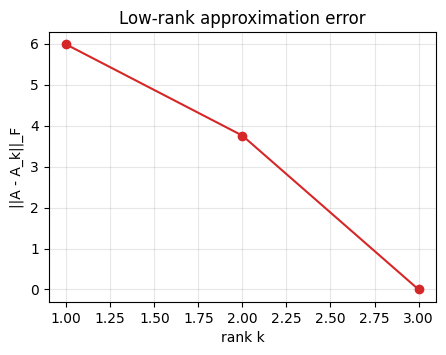

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors) + 1), errors, marker="o", color="tab:red")
plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

The approximation error decreases as k increases. This means that once k reaches the full rank, the approximation becomes the original matrix up to numerical roundoff.

## 1.4.3 Principal Component Analysis

Principal component analysis finds directions of maximum variation in centered data. PCA can be computed using SVD: after centering the data matrix X, the rows of V^T give principal component directions.

In [ ]:
# Make matrix X
X = np.array([
    [4.2, 3.8],
    [1.1, 1.5],
    [3.5, 3.1],
    [2.8, 2.5],
    [5.0, 4.6],
    [3.9, 3.4],
    [2.2, 2.0],
    [1.5, 1.2],
    [4.6, 4.1],
    [2.0, 1.9],
], dtype=float)

# Find mean and calculate PCA
mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ Vt_pca.T
explained_variance = (s_pca**2) / (len(X) - 1)
explained_ratio = explained_variance / explained_variance.sum()

print("feature means =", mean)
print("principal directions as rows of Vt =")
print(Vt_pca)
print("singular values =", s_pca)
print("explained variance =", explained_variance)
print("explained variance ratio =", explained_ratio)
print("first three PCA scores =")
print(scores[:3])

feature means = [3.08 2.81]
principal directions as rows of Vt =
[[-0.7595 -0.6505]
 [ 0.6505 -0.7595]]
singular values = [5.3435 0.3894]
explained variance = [3.1726 0.0168]
explained variance ratio = [0.9947 0.0053]
first three PCA scores =
[[-1.4946 -0.0234]
 [ 2.356  -0.293 ]
 [-0.5076  0.0529]]


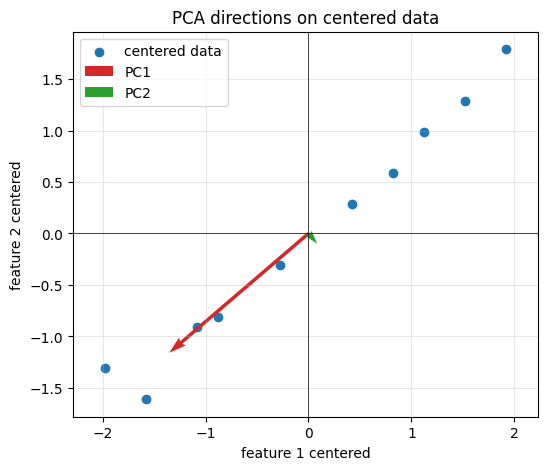

In [ ]:
origin = np.zeros(2)
pc1 = Vt_pca[0] * s_pca[0] / np.sqrt(len(X) - 1)
pc2 = Vt_pca[1] * s_pca[1] / np.sqrt(len(X) - 1)

plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")
plt.quiver(*origin, *pc1, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*origin, *pc2, angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

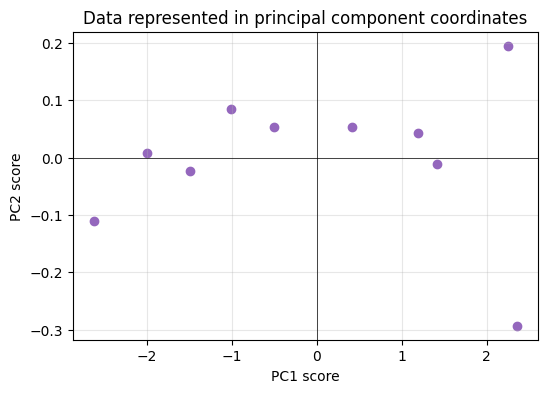

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(scores[:, 0], scores[:, 1], color="tab:purple")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data represented in principal component coordinates")
plt.grid(True, alpha=0.3)
plt.show()

The first principal component explains the largest share of variance. Projecting data onto PC1 and PC2 rotates the coordinate system so the strongest variation appears along the first axis.

## Reflection and Rubric Checklist

- Code Accuracy and Completeness: There were no errors when running
- Math Concept Coverage: SVD, low rank appropximation, and PCA were all calculated and shown
- Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- Explanation and Documentation: I explained each code section and how it relates to the concept
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed around multiple examples and ensured calculations were still correct